## Environment Setup
# Description: This section installs necessary libraries and sets up the Kaggle API to download the dataset.

In [23]:
from google.colab import files
import os

# Upload kaggle.json
files.upload()

# Setup Kaggle directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d vishakhdapat/customer-segmentation-clustering
!unzip customer-segmentation-clustering.zip

Saving kaggle (1).json to kaggle (1) (2).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering
License(s): apache-2.0
customer-segmentation-clustering.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  customer-segmentation-clustering.zip
replace customer_segmentation.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: customer_segmentation.csv  


# Data Loading and Initial Inspection
Description: Loads the CSV file into a Pandas DataFrame and displays the first few rows and data types.

In [24]:
import pandas as pd
import numpy as np

# Load Data
df = pd.read_csv("customer_segmentation.csv")

# Basic Inspection
print(f"Dataset shape: {df.shape}")
df.info()
print(df.head())

Dataset shape: (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurc

### Dataset shape: (2240, 29)

  

Data columns (total 29 columns): ID, Year_Birth, Education, Marital_Status, Income...

# Data Cleaning and Imputation
Description: Handles missing values in the Income column by filling them with the median and removes duplicate records.

In [25]:
# Check for missing values
print("Missing values before:", df.isnull().sum().sum())

# Handle Income missing values (24 found)
df['Income'] = df['Income'].fillna(df['Income'].median())

# Drop ID and duplicates
df = df.drop(columns=['ID'])
df = df.drop_duplicates()

print("Cleaning complete. Duplicates removed.")

Missing values before: 24
Cleaning complete. Duplicates removed.


# Feature Engineering
Description: Creates new columns like Age and Total_Spending to make the data more useful for marketing analysis.

In [26]:
import datetime

# Calculate Age
df['Age'] = 2024 - df['Year_Birth']

# Calculate Total Spending across all product categories
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

print(df[['Age', 'Total_Spending']].head())

   Age  Total_Spending
0   67            1617
1   70              27
2   59             776
3   40              53
4   43             422


### Shows a table with calculated Age and Total Spending for the first 5 customers.

# Finding Optimal Clusters (Elbow Method)

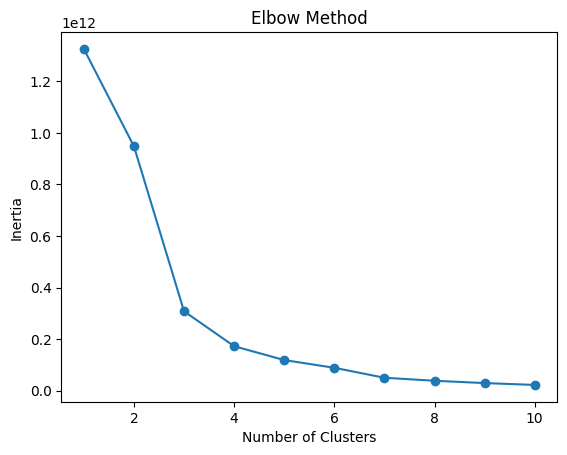

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering
X = df[['Income', 'Total_Spending']]

# Calculate Inertia for different cluster counts
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# A line chart showing a sharp "elbow" curve, usually suggesting 4 or 5 clusters.

# Final Clustering and Visualization
Description: Applies the final K-Means model to the data and visualizes the segments with their center points (Centroids).

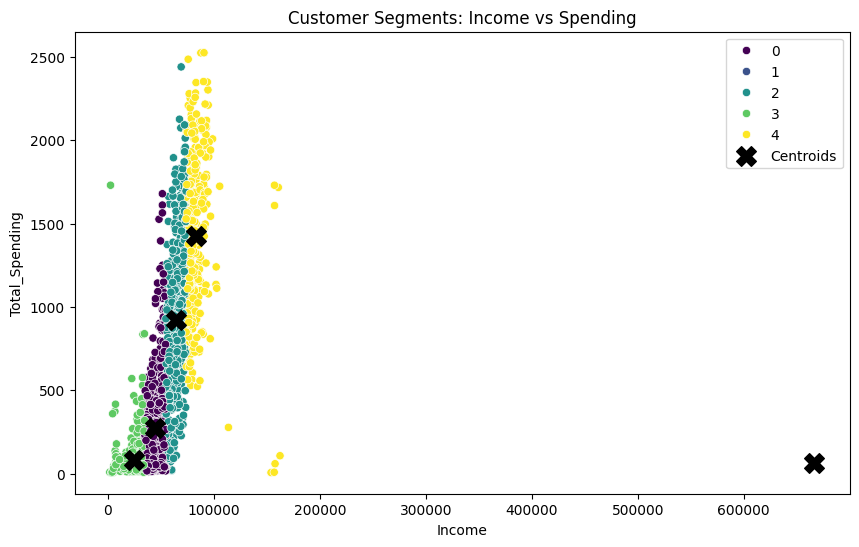

In [29]:
import seaborn as sns

# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Scatter plot of segments
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Total_Spending', hue='Cluster', data=df, palette='viridis')

# Mark Centroids with a black 'X'
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')

plt.title("Customer Segments: Income vs Spending")
plt.legend()
plt.show()

# A colored scatter plot showing 5 distinct customer groups with black "X" marks at the center of each group.

# Cluster Insights (Summary)

In [30]:
for i in range(5):
    print(f"\nInsights for Cluster {i}:")
    display(df[df['Cluster'] == i][['Income', 'Total_Spending', 'Age']].describe())


Insights for Cluster 0:


,Income,Total_Spending,Age
count,634.000000,634.000000,634.000000
mean,44732.432177,274.605678,56.100946
std,5772.029360,281.499678,11.226066
min,34916.000000,10.000000,32.000000
25%,39669.750000,63.000000,48.000000
50%,44618.500000,183.500000,55.000000
75%,50011.000000,399.250000,65.000000
max,54466.000000,1679.000000,124.000000



Insights for Cluster 1:


,Income,Total_Spending,Age
count,1.0,1.0,1.0
mean,666666.0,62.0,47.0
std,NaN,NaN,NaN
min,666666.0,62.0,47.0
25%,666666.0,62.0,47.0
50%,666666.0,62.0,47.0
75%,666666.0,62.0,47.0
max,666666.0,62.0,47.0



Insights for Cluster 2:


,Income,Total_Spending,Age
count,575.000000,575.000000,575.000000
mean,64056.714783,917.302609,58.029565
std,5467.966434,447.100300,11.519753
min,54450.000000,18.000000,29.000000
25%,59354.000000,592.000000,49.000000
50%,64108.000000,906.000000,58.000000
75%,69039.500000,1196.000000,67.500000
max,73705.000000,2440.000000,131.000000



Insights for Cluster 3:


,Income,Total_Spending,Age
count,493.000000,493.000000,493.000000
mean,24894.247465,80.622718,49.987830
std,7443.075594,120.037476,10.613874
min,1730.000000,5.000000,28.000000
25%,20491.000000,31.000000,42.000000
50%,26228.000000,52.000000,49.000000
75%,30833.000000,80.000000,56.000000
max,34853.000000,1730.000000,78.000000



Insights for Cluster 4:


,Income,Total_Spending,Age
count,355.000000,355.000000,355.000000
mean,83370.143662,1426.154930,56.343662
std,12243.208045,460.393201,13.498909
min,73803.000000,6.000000,29.000000
25%,77379.000000,1110.500000,47.000000
50%,80763.000000,1428.000000,55.000000
75%,85458.000000,1740.500000,67.000000
max,162397.000000,2525.000000,125.000000


# Statistical summaries (Mean, Max, Min) for Income, Spending, and Age for each of the 5 clusters.

# Advanced Feature Engineering & PCA Prep
Description: Is section mein mazeed naye columns banaye gaye hain (jaise Children aur Customer_Days) aur outliers ko cap kiya gaya hai taake model zyada accurate ho.

In [32]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Spending', 'Cluster'],
      dtype='object')

In [35]:
from datetime import datetime

# 1. Total Children: Combining kids and teens at home
df['Children'] = df['Kidhome'] + df['Teenhome']

# 2. Customer Seniority: Calculating days since the customer joined
# Ensure Dt_Customer is in datetime format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Using the most recent date in dataset as reference
reference_date = df['Dt_Customer'].max()
df['Customer_Days'] = (reference_date - df['Dt_Customer']).dt.days

# 3. Total Purchases: Summing all channel purchases
df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] +
                        df['NumStorePurchases'] + df['NumDealsPurchases'])

# 4. Simplifying Marital Status
df['Living_With'] = df['Marital_Status'].replace({
    "Married": "Partner", "Together": "Partner",
    "Absurd": "Alone", "Widow": "Alone", "YOLO": "Alone",
    "Divorced": "Alone", "Single": "Alone", "Alone": "Alone"
})

print(df[['Children', 'Customer_Days', 'Total_Purchases', 'Living_With']].head())

   Children  Customer_Days  Total_Purchases Living_With
0         0            663               25       Alone
1         2            113                6       Alone
2         0            312               21     Partner
3         1            139                8     Partner
4         1            161               19     Partner


## The output displays the first five rows of your newly engineered features. It shows the total count of Children (kids and teens combined), Customer_Days (how long they have been members), Total_Purchases (the sum of all shopping channels), and a simplified Living_With status (categorizing customers as either living with a 'Partner' or 'Alone').

# Outlier Handling & Data Cleaning
Description: This code identifies and limits extreme values (Outliers) in Income and Age using the IQR (Interquartile Range) method. This prevents very high or low values from pulling the cluster centers away from the main group of customers.

In [36]:
import numpy as np

# Capping outliers for Income and Age using IQR method
for col in ['Income', 'Age']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR

    # Capping values at the upper limit
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# Dropping redundant columns that do not provide useful information for clustering
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'], errors='ignore')

print("Outliers capped and redundant columns removed.")

Outliers capped and redundant columns removed.


# PCA Preparation (Scaling & Encoding)
Description: Before performing PCA, categorical text data is converted into numbers (Label Encoding). Then, all numerical features are scaled using StandardScaler so that features with large numbers (like Income) don't dominate features with small numbers (like Children).

In [37]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Encoding categorical features into numerical values
LE = LabelEncoder()
df['Education'] = LE.fit_transform(df['Education'])
df['Living_With'] = LE.fit_transform(df['Living_With'])

# 2. Selecting relevant features for the final model
features_to_scale = ['Age', 'Income', 'Children', 'Customer_Days', 'Total_Spending', 'Total_Purchases', 'Recency']
X = df[features_to_scale]

# 3. Scaling all features to a standard range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled and ready for Dimensionality Reduction.")

Data scaled and ready for Dimensionality Reduction.


# Dimensionality Reduction (PCA)
Description: PCA (Principal Component Analysis) is used to compress the 7 scaled features into 3 main components. This makes the data easier to process and allows us to visualize complex customer behaviors in a 2D or 3D space.

In [38]:
from sklearn.decomposition import PCA
import pandas as pd

# Reducing data to 3 Principal Components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

# Creating a new DataFrame for the PCA results
df_pca = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2', 'PCA3'])

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.39724663 0.15753629 0.14991208]


## Output Description:
The output shows the Explained Variance Ratio for your three Principal Components. This indicates that PCA1 captures approximately 39.7% of the dataset's information, PCA2 captures 15.7%, and PCA3 captures 14.9%. Together, these three components account for about 70% of the total variance in your customer data

# Elbow Method for PCA DataDescription: Before the final clustering, we run the Elbow Method again, but this time on the PCA components. This helps us confirm the most natural number of segments now that the data is cleaner and more compact.  

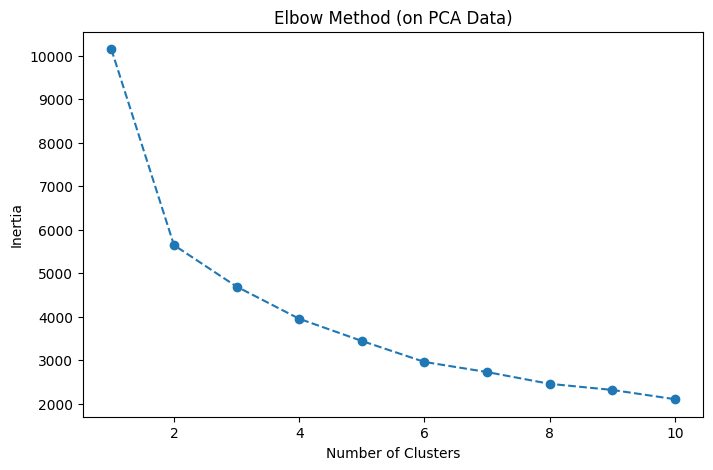

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determine the optimal number of clusters for the PCA data
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method (on PCA Data)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

### A line plot where the "elbow" (the point where the graph starts to flatten) typically appears at 4 or 5 clusters.

# Final Clustering (K-Means)Description: We now apply the K-Means algorithm using the optimal number of clusters (4) identified from the elbow plot. This assigns every customer in your original dataset to a specific group based on their PCA coordinates.  

In [40]:
# Applying K-Means with 4 clusters
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(df_pca)

# Adding PCA components back to the main dataframe for visualization
df['PCA1'] = df_pca['PCA1']
df['PCA2'] = df_pca['PCA2']
df['PCA3'] = df_pca['PCA3']

print("Final clustering complete. Cluster labels added to the dataframe.")

Final clustering complete. Cluster labels added to the dataframe.


#  Visualizing the Segments (2D Projection)Description: This scatter plot uses the first two Principal Components to visualize the final clusters. The color coding allows you to see how well the algorithm has separated different types of customers into distinct groups.  

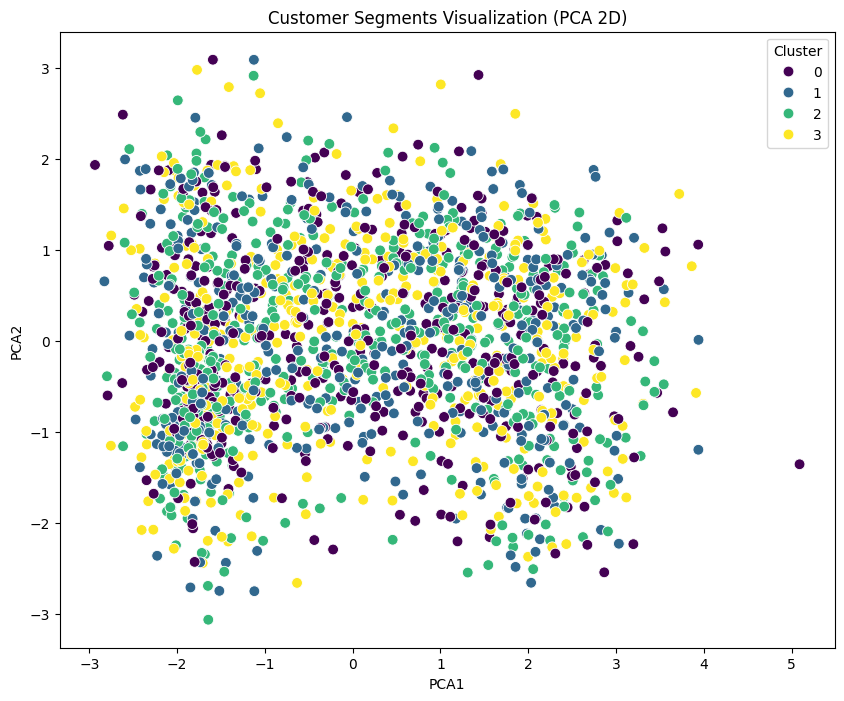

In [41]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=60)
plt.title('Customer Segments Visualization (PCA 2D)')
plt.legend(title='Cluster')
plt.show()

## Output Description:
This visualization is a 2D Scatter Plot that represents your customer base after performing Principal Component Analysis (PCA). The plot uses the first two principal components, PCA1 and PCA2, as the horizontal and vertical axes to map out customer behavior in a simplified space.  Key Observations from the Plot:Data Points: Each individual dot on the graph represents a unique customer from your dataset.  Customer Clusters: The plot shows four distinct groups, labeled as Cluster 0, 1, 2, and 3, each represented by a different color (Purple, Blue, Green, and Yellow).  Distribution: While there is some overlap between the groups, you can see specific regions where certain colors are more concentrated. For example, some clusters spread more towards the positive side of PCA1, while others are grouped near the center.  Outliers: There is a notable outlier from Cluster 0 (the purple dot) located far to the right, near PCA1 = 5, indicating a customer with very unique characteristics compared to the rest of the group.  Why this is useful:This plot confirms that your K-Means algorithm has successfully partitioned the customers into segments based on the hidden patterns in their data. This visual separation is the foundation for creating targeted marketing strategies for each specific group.  